In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
import torch
import pandas as pd
from torch import optim
import numpy as np

In [20]:
features, target = fetch_california_housing(return_X_y = True, as_frame = True)
features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, random_state = 42)

In [22]:
y_test.shape

(5160,)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train = np.array(y_train)
y_test = np.array(y_test)


y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

In [24]:
X_train_tensor.shape

torch.Size([15480, 8])

In [25]:
y_train_tensor.shape

torch.Size([15480, 1])

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth = 5)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Model Creation

In [27]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(nn.Linear(input_size,hidden_size),
                                     nn.ReLU(),
                                    nn.Linear(hidden_size,output_size))
    def forward(self, x):
        return self.network(x)

In [28]:
input_size = 8
hidden_size = 12
output_size = 1

model = SimpleNN(input_size, hidden_size, output_size)

In [29]:
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 1500
for epoch in range(epochs):
    model.train()  # Set the model to training mode

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/1500], Loss: 6.5789
Epoch [20/1500], Loss: 6.3138
Epoch [30/1500], Loss: 6.0539
Epoch [40/1500], Loss: 5.7974
Epoch [50/1500], Loss: 5.5419
Epoch [60/1500], Loss: 5.2852
Epoch [70/1500], Loss: 5.0261
Epoch [80/1500], Loss: 4.7644
Epoch [90/1500], Loss: 4.5004
Epoch [100/1500], Loss: 4.2354
Epoch [110/1500], Loss: 3.9709
Epoch [120/1500], Loss: 3.7090
Epoch [130/1500], Loss: 3.4517
Epoch [140/1500], Loss: 3.2014
Epoch [150/1500], Loss: 2.9604
Epoch [160/1500], Loss: 2.7306
Epoch [170/1500], Loss: 2.5140
Epoch [180/1500], Loss: 2.3119
Epoch [190/1500], Loss: 2.1256
Epoch [200/1500], Loss: 1.9558
Epoch [210/1500], Loss: 1.8026
Epoch [220/1500], Loss: 1.6659
Epoch [230/1500], Loss: 1.5449
Epoch [240/1500], Loss: 1.4387
Epoch [250/1500], Loss: 1.3461
Epoch [260/1500], Loss: 1.2658
Epoch [270/1500], Loss: 1.1962
Epoch [280/1500], Loss: 1.1360
Epoch [290/1500], Loss: 1.0837
Epoch [300/1500], Loss: 1.0381
Epoch [310/1500], Loss: 0.9984
Epoch [320/1500], Loss: 0.9635
Epoch [330/1500],

### Model Evaluation

Test Loss: 0.4154


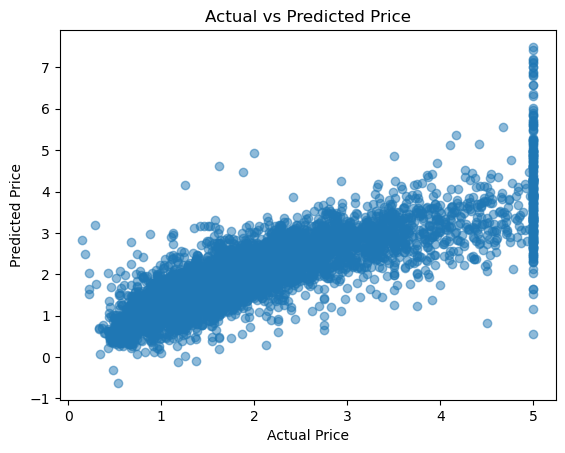

In [30]:
model.eval()  # This sets the model to evaluation mode
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

# Plotting our results
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions.numpy(), alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()


In [32]:
from sklearn.metrics import r2_score, root_mean_squared_error as rmse

# Evaluate the model
#model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    actuals = y_test_tensor.numpy()

r2 = r2_score(actuals, predictions)
print(f'R2 score: {r2:.4f}')

R2 score: 0.6861


In [33]:
rmse(actuals, predictions)

0.6445139050483704

## Using NN for cancer prediction

In [35]:
from sklearn.datasets import load_breast_cancer

In [36]:
X, y = load_breast_cancer(as_frame = True, return_X_y=True)

In [37]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [38]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64